# Predictive Meta-Modeling

This notebook is a direct continuation of `01_mfa.ipynb`. It loads the dataset-level, preprocessed, redundancy-reduced matrices exported by `01_mfa.ipynb` and asks a separate question from the association analysis:

> Can the reduced meta-feature matrices predict the dataset-level performance gap out of sample?

This is an exploratory predictive analysis, not a causal or confirmatory inference step.

## Minimal Predictive Protocol

We evaluate the regression/classification matrix and the classification-augmented matrix separately. Each row is one dataset. The target is `delta_norm`.

For each matrix, we compare a mean-only baseline with ridge regression under leave-one-dataset-out cross-validation. Control-only and controls-plus-meta-feature variants use controls fixed by analysis matrix, not by model-family comparison: the general matrix uses `log_n`, `log_d`, `d_over_n`, `cat_fraction`, and `feature_missing_fraction`; the classification-augmented matrix adds `n_classes` and `class_imbalance_ratio`. When robust univariate survivors from `01_mfa.ipynb` are available, we also report a ridge model with fixed controls plus those robust features. All-meta-feature predictive models remain unchanged. We additionally include a shallow decision tree and, when `xgboost` is installed, a strongly regularized XGBoost model as nonlinear predictive sensitivity checks. Imputation, scaling where used, and model fitting are performed inside each training fold. We report out-of-sample error, rank agreement, and sign accuracy. Coefficient summaries are reported only for ridge models and are descriptive, not hypothesis tests.


In [1]:
from __future__ import annotations

import json
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

PREDICTIVE_ENABLE_TABPFN = globals().get("PREDICTIVE_ENABLE_TABPFN", False)
if PREDICTIVE_ENABLE_TABPFN:
    try:
        from tabpfn import TabPFNRegressor
    except ImportError:
        TabPFNRegressor = None
else:
    TabPFNRegressor = None


def _project_dir_for_notebook_handoff() -> Path:
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "meta-feature-analysis",
    ]
    for candidate in candidates:
        if (candidate / "src" / "mfa").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError(
        "Run this notebook from the repository root or notebooks/ directory."
    )


from dotenv import load_dotenv

load_dotenv()

# Mirror 01_mfa.ipynb's per-config handoff layout so this notebook always
# reads the artifacts that match the currently selected config + hash, not
# any stale legacy copy that may live in the bare notebook_handoff/ dir.
CONFIG = globals().get("CONFIG", "config_2.yaml")

MFA_PROJECT_DIR = _project_dir_for_notebook_handoff()
sys.path.insert(0, str(MFA_PROJECT_DIR / "src"))
sys.path.insert(0, str(MFA_PROJECT_DIR.parent / "tabarena" / "tabarena"))

from mfa import load_config  # noqa: E402
from mfa.cache import compute_config_hash  # noqa: E402

_config_path = MFA_PROJECT_DIR / "configs" / CONFIG
_config = load_config(_config_path)
_yaml_n_jobs = _config.parallelism.n_jobs
_effective_n_jobs = min(_yaml_n_jobs, 2) if _yaml_n_jobs > 0 else 2
_run_config = replace(
    _config,
    parallelism=replace(_config.parallelism, n_jobs=_effective_n_jobs),
)
MFA_CONFIG_HASH = globals().get(
    "MFA_CONFIG_HASH", compute_config_hash(_run_config.to_dict())
)
MFA_HANDOFF_DIR = (
    MFA_PROJECT_DIR
    / ".mfa_cache"
    / "notebook_handoff"
    / f"{_config_path.stem}_{MFA_CONFIG_HASH}"
)
MFA_HANDOFF_METADATA_PATH = MFA_HANDOFF_DIR / "metadata.json"
MFA_HANDOFF_METADATA = (
    json.loads(MFA_HANDOFF_METADATA_PATH.read_text(encoding="utf-8"))
    if MFA_HANDOFF_METADATA_PATH.exists()
    else {}
)
print(f"02_mfa handoff dir: {MFA_HANDOFF_DIR}")

MFA_FIGURES_DIR = (
    MFA_PROJECT_DIR
    / "figures"
    / f"{_config_path.stem}_{MFA_CONFIG_HASH}"
    / "predictive"
)
PREDICTIVE_EXPORT_FIGURES = globals().get("PREDICTIVE_EXPORT_FIGURES", True)
PREDICTIVE_FIGURE_EXPORT_DIR = Path(
    globals().get("PREDICTIVE_FIGURE_EXPORT_DIR", MFA_FIGURES_DIR)
)
PREDICTIVE_FIGURE_DPI = globals().get("PREDICTIVE_FIGURE_DPI", 300)
plt.rcParams.update(
    {
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": PREDICTIVE_FIGURE_DPI,
    }
)
print(f"02_mfa figure dir: {PREDICTIVE_FIGURE_EXPORT_DIR}")

if "available_context_columns" not in globals() and MFA_HANDOFF_METADATA:
    available_context_columns = set(
        MFA_HANDOFF_METADATA.get("available_context_columns", [])
    )

PREDICTIVE_TARGET = globals().get(
    "ASSOCIATION_TARGET", MFA_HANDOFF_METADATA.get("target", "delta_norm")
)
PREDICTIVE_UNIT_COLUMN = globals().get(
    "INDEPENDENT_UNIT_COLUMN", MFA_HANDOFF_METADATA.get("unit_column", "dataset")
)
PREDICTIVE_MIN_N = globals().get("ASSOCIATION_MIN_N", 30)
PREDICTIVE_RIDGE_ALPHAS = np.logspace(-3, 3, 13)
PREDICTIVE_TOP_COEFFICIENTS = 20
PREDICTIVE_TREE_MAX_DEPTH = 2
PREDICTIVE_TREE_MIN_SAMPLES_LEAF = 5
PREDICTIVE_RANDOM_STATE = 20260424

PREDICTIVE_GENERAL_CONTROLS = [
    "log_n",
    "log_d",
    "d_over_n",
    "cat_fraction",
    "feature_missing_fraction",
]

PREDICTIVE_CLASSIFICATION_CONTROLS = [
    "n_classes",
    "class_imbalance_ratio",
]

02_mfa handoff dir: /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/.mfa_cache/notebook_handoff/config_2_781b7f9c27428458
02_mfa figure dir: /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/figures/config_2_781b7f9c27428458/predictive


## Load Handoff Artifacts

If the reduced matrices are already in memory, they are used as-is. Otherwise, this notebook loads the artifacts written by the export cell in `01_mfa.ipynb`.

In [2]:
MFA_REQUIRED_HANDOFF_TABLES = {
    "analysis_general_reduced": "analysis_general_reduced.pkl",
    "analysis_classification_reduced": "analysis_classification_reduced.pkl",
    "robust_general_associations": "robust_general_associations.pkl",
    "robust_classification_associations": "robust_classification_associations.pkl",
}

missing_handoff_tables = [
    table_name
    for table_name in MFA_REQUIRED_HANDOFF_TABLES
    if table_name not in globals()
]

if missing_handoff_tables:
    missing_paths = [
        MFA_HANDOFF_DIR / file_name
        for table_name, file_name in MFA_REQUIRED_HANDOFF_TABLES.items()
        if table_name in missing_handoff_tables
        and not (MFA_HANDOFF_DIR / file_name).exists()
    ]
    if missing_paths:
        raise FileNotFoundError(
            "Missing MFA handoff artifacts. Run the export cell at the end of "
            f"01_mfa.ipynb first. Missing files: {missing_paths}"
        )

    for table_name in missing_handoff_tables:
        globals()[table_name] = pd.read_pickle(
            MFA_HANDOFF_DIR / MFA_REQUIRED_HANDOFF_TABLES[table_name]
        )
    print(f"Loaded MFA handoff artifacts from {MFA_HANDOFF_DIR}")
else:
    print("Using reduced analysis matrices already present in memory.")

handoff_summary = []
for table_name in MFA_REQUIRED_HANDOFF_TABLES:
    table = globals()[table_name]
    handoff_summary.append(
        {
            "table": table_name,
            "rows": int(len(table)),
            "columns": int(table.shape[1]),
            "unique_units": (
                int(table[PREDICTIVE_UNIT_COLUMN].nunique(dropna=False))
                if PREDICTIVE_UNIT_COLUMN in table.columns
                else None
            ),
        }
    )

display(pd.DataFrame(handoff_summary))

Loaded MFA handoff artifacts from /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/.mfa_cache/notebook_handoff/config_2_781b7f9c27428458


,table,rows,columns,unique_units
0,analysis_general_reduced,51,302,51.0
1,analysis_classification_reduced,38,576,38.0
2,robust_general_associations,0,13,NaN
3,robust_classification_associations,0,13,NaN


In [3]:
def _predictive_context_columns() -> set[str]:
    context = set(globals().get("available_context_columns", []))
    context.update(
        {
            PREDICTIVE_UNIT_COLUMN,
            PREDICTIVE_TARGET,
            "comparison_name",
            "task_type",
            "dataset",
        }
    )
    return context


def _assert_dataset_level_for_prediction(
    table: pd.DataFrame,
    *,
    table_name: str,
) -> dict[str, int | str]:
    if PREDICTIVE_UNIT_COLUMN not in table.columns:
        raise KeyError(f"{table_name} is missing {PREDICTIVE_UNIT_COLUMN!r}.")
    n_rows = len(table)
    n_units = table[PREDICTIVE_UNIT_COLUMN].nunique(dropna=False)
    duplicate_mask = table[PREDICTIVE_UNIT_COLUMN].duplicated(keep=False)
    if duplicate_mask.any():
        duplicate_units = (
            table.loc[duplicate_mask, PREDICTIVE_UNIT_COLUMN]
            .drop_duplicates()
            .head(10)
            .tolist()
        )
        raise ValueError(
            f"{table_name} is not dataset-level: {n_rows} rows but {n_units} unique "
            f"{PREDICTIVE_UNIT_COLUMN} values. Repeated examples: {duplicate_units}."
        )
    return {
        "analysis_table": table_name,
        "independent_unit": PREDICTIVE_UNIT_COLUMN,
        "rows": n_rows,
        "unique_units": n_units,
    }


def _numeric_usable(series: pd.Series, *, min_n: int = 3) -> bool:
    values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    values = values.dropna()
    return len(values) >= min_n and values.nunique() > 1


def _feature_columns_for_prediction(table: pd.DataFrame) -> list[str]:
    context = _predictive_context_columns()
    columns = []
    for column in table.columns:
        if column in context:
            continue
        if _numeric_usable(table[column]):
            columns.append(column)
    return columns


def _available_controls(
    table: pd.DataFrame,
    *,
    include_classification_controls: bool,
) -> tuple[list[str], pd.DataFrame]:
    candidates = list(PREDICTIVE_GENERAL_CONTROLS)
    if include_classification_controls:
        candidates.extend(PREDICTIVE_CLASSIFICATION_CONTROLS)

    selected = []
    rows = []
    for control_name in candidates:
        available = control_name in table.columns and _numeric_usable(
            table[control_name]
        )
        if available:
            selected.append(control_name)
        rows.append(
            {
                "control": control_name,
                "selected_column": control_name if available else None,
                "available": available,
            }
        )
    return selected, pd.DataFrame(rows)


def _robust_feature_columns(
    table: pd.DataFrame,
    robust_table: pd.DataFrame | None,
    *,
    excluded_columns: set[str],
) -> list[str]:
    if (
        robust_table is None
        or robust_table.empty
        or "feature" not in robust_table.columns
    ):
        return []
    columns = []
    for feature in robust_table["feature"].dropna().astype(str):
        if feature in excluded_columns or feature in columns:
            continue
        if feature in table.columns and _numeric_usable(table[feature]):
            columns.append(feature)
    return columns


def _ridge_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scaler", StandardScaler()),
            ("ridge", RidgeCV(alphas=PREDICTIVE_RIDGE_ALPHAS, cv=None)),
        ]
    )


def _tree_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            (
                "tree",
                DecisionTreeRegressor(
                    max_depth=PREDICTIVE_TREE_MAX_DEPTH,
                    min_samples_leaf=PREDICTIVE_TREE_MIN_SAMPLES_LEAF,
                    random_state=PREDICTIVE_RANDOM_STATE,
                ),
            ),
        ]
    )


def _xgboost_pipeline() -> Pipeline | None:
    if XGBRegressor is None:
        return None
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            (
                "xgboost",
                XGBRegressor(
                    objective="reg:squarederror",
                    n_estimators=50,
                    max_depth=1,
                    learning_rate=0.05,
                    subsample=0.80,
                    colsample_bytree=0.80,
                    min_child_weight=5,
                    reg_alpha=1.0,
                    reg_lambda=10.0,
                    random_state=PREDICTIVE_RANDOM_STATE,
                    n_jobs=1,
                    verbosity=0,
                ),
            ),
        ]
    )


def _tabpfn_pipeline() -> Pipeline | None:
    if TabPFNRegressor is None:
        return None
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            (
                "tabpfn",
                TabPFNRegressor(
                    n_estimators=8,
                    ignore_pretraining_limits=True,
                    random_state=PREDICTIVE_RANDOM_STATE,
                    n_preprocessing_jobs=1,
                ),
            ),
        ]
    )


def _estimator_for_model(model_family: str) -> Pipeline | DummyRegressor | None:
    if model_family == "mean":
        return DummyRegressor(strategy="mean")
    if model_family == "ridge":
        return _ridge_pipeline()
    if model_family == "tree":
        return _tree_pipeline()
    if model_family == "xgboost":
        return _xgboost_pipeline()
    if model_family == "tabpfn":
        return _tabpfn_pipeline()
    raise ValueError(f"Unknown model family: {model_family!r}.")


def _model_predictions(
    data: pd.DataFrame,
    predictors: list[str],
    *,
    model_name: str,
    model_family: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    y = data[PREDICTIVE_TARGET].astype(float).to_numpy()
    prediction_rows = []
    coefficient_rows = []
    estimator_template = _estimator_for_model(model_family)

    if estimator_template is None:
        return pd.DataFrame(), pd.DataFrame()

    for test_idx in range(len(data)):
        train_idx = np.array([idx for idx in range(len(data)) if idx != test_idx])
        train = data.iloc[train_idx]
        test = data.iloc[[test_idx]]
        y_train = y[train_idx]

        if predictors:
            estimator = _estimator_for_model(model_family)
            estimator.fit(train[predictors], y_train)
            y_pred = float(estimator.predict(test[predictors])[0])
            alpha = np.nan
            if model_family == "ridge":
                alpha = float(estimator.named_steps["ridge"].alpha_)
                coefficients = estimator.named_steps["ridge"].coef_
                for predictor, coefficient in zip(
                    predictors, coefficients, strict=True
                ):
                    coefficient_rows.append(
                        {
                            "model": model_name,
                            "held_out_dataset": test[PREDICTIVE_UNIT_COLUMN].iloc[0],
                            "predictor": predictor,
                            "coefficient": float(coefficient),
                            "alpha": alpha,
                        }
                    )
        else:
            estimator = _estimator_for_model("mean")
            estimator.fit(np.zeros((len(train), 1)), y_train)
            y_pred = float(estimator.predict(np.zeros((1, 1)))[0])
            alpha = np.nan

        prediction_rows.append(
            {
                "model": model_name,
                "model_family": model_family,
                "dataset": test[PREDICTIVE_UNIT_COLUMN].iloc[0],
                "y_true": float(y[test_idx]),
                "y_pred": y_pred,
                "alpha": alpha,
            }
        )

    return pd.DataFrame(prediction_rows), pd.DataFrame(coefficient_rows)


def _prediction_metrics(predictions: pd.DataFrame) -> dict[str, float | int]:
    if predictions.empty:
        return {
            "n": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "oos_r2": np.nan,
            "spearman_pred_obs": np.nan,
            "sign_accuracy": np.nan,
            "median_alpha": np.nan,
        }

    y_true = predictions["y_true"].astype(float).to_numpy()
    y_pred = predictions["y_pred"].astype(float).to_numpy()
    sse = float(np.sum((y_true - y_pred) ** 2))
    sst = float(np.sum((y_true - y_true.mean()) ** 2))
    nonzero_mask = y_true != 0

    if np.unique(y_true).size > 1 and np.unique(y_pred).size > 1:
        spearman = float(stats.spearmanr(y_true, y_pred).statistic)
    else:
        spearman = np.nan

    return {
        "n": int(len(predictions)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "oos_r2": float(1 - sse / sst) if sst > 0 else np.nan,
        "spearman_pred_obs": spearman,
        "sign_accuracy": (
            float(
                np.mean(np.sign(y_true[nonzero_mask]) == np.sign(y_pred[nonzero_mask]))
            )
            if nonzero_mask.any()
            else np.nan
        ),
        "median_alpha": (
            float(predictions["alpha"].dropna().median())
            if predictions["alpha"].notna().any()
            else np.nan
        ),
    }


def _coefficient_summary(
    coefficients: pd.DataFrame,
    *,
    feature_columns: list[str],
    top_n: int = PREDICTIVE_TOP_COEFFICIENTS,
) -> pd.DataFrame:
    if coefficients.empty:
        return pd.DataFrame()
    feature_set = set(feature_columns)
    coef = coefficients[coefficients["predictor"].isin(feature_set)].copy()
    if coef.empty:
        return pd.DataFrame()
    observed_direction = np.sign(coef["coefficient"])
    coef["nonzero_direction"] = observed_direction.where(
        observed_direction != 0, np.nan
    )
    summary = (
        coef.groupby(["model", "predictor"], as_index=False)
        .agg(
            median_standardized_coefficient=("coefficient", "median"),
            median_abs_standardized_coefficient=(
                "coefficient",
                lambda values: float(np.median(np.abs(values))),
            ),
            q05_standardized_coefficient=(
                "coefficient",
                lambda values: float(np.quantile(values, 0.05)),
            ),
            q95_standardized_coefficient=(
                "coefficient",
                lambda values: float(np.quantile(values, 0.95)),
            ),
            positive_fold_share=(
                "coefficient",
                lambda values: float(np.mean(np.asarray(values) > 0)),
            ),
            negative_fold_share=(
                "coefficient",
                lambda values: float(np.mean(np.asarray(values) < 0)),
            ),
        )
        .sort_values(
            ["model", "median_abs_standardized_coefficient", "predictor"],
            ascending=[True, False, True],
        )
    )
    summary["coefficient_sign_consistency"] = summary[
        ["positive_fold_share", "negative_fold_share"]
    ].max(axis=1)
    return summary.groupby("model", group_keys=False).head(top_n).reset_index(drop=True)


def run_predictive_meta_modeling(
    table: pd.DataFrame,
    *,
    table_name: str,
    include_classification_controls: bool,
    robust_table: pd.DataFrame | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    guard = pd.DataFrame(
        [_assert_dataset_level_for_prediction(table, table_name=table_name)]
    )
    if PREDICTIVE_TARGET not in table.columns:
        raise KeyError(f"{table_name} is missing target column {PREDICTIVE_TARGET!r}.")

    feature_columns = _feature_columns_for_prediction(table)
    control_columns, control_report = _available_controls(
        table,
        include_classification_controls=include_classification_controls,
    )
    feature_columns = [
        column for column in feature_columns if column not in set(control_columns)
    ]
    robust_feature_columns = _robust_feature_columns(
        table,
        robust_table,
        excluded_columns=set(control_columns),
    )
    control_report.insert(0, "analysis_table", table_name)

    modeling_columns = [
        PREDICTIVE_UNIT_COLUMN,
        PREDICTIVE_TARGET,
        *control_columns,
        *feature_columns,
    ]
    data = table.loc[:, list(dict.fromkeys(modeling_columns))].copy()
    for column in data.columns:
        if column == PREDICTIVE_UNIT_COLUMN:
            continue
        data[column] = pd.to_numeric(data[column], errors="coerce")
    data = data.replace([np.inf, -np.inf], np.nan)
    data = data[data[PREDICTIVE_TARGET].notna()].reset_index(drop=True)

    model_specs = [("mean_baseline", "mean", [])]
    if control_columns:
        model_specs.append(("ridge_controls", "ridge", control_columns))
    model_specs.append(("ridge_meta_features", "ridge", feature_columns))
    if control_columns:
        model_specs.append(
            (
                "ridge_controls_plus_meta_features",
                "ridge",
                control_columns + feature_columns,
            )
        )
    if robust_feature_columns:
        model_specs.append(("ridge_robust_features", "ridge", robust_feature_columns))
    if control_columns and robust_feature_columns:
        model_specs.append(
            (
                "ridge_controls_plus_robust_features",
                "ridge",
                control_columns + robust_feature_columns,
            )
        )
    if control_columns:
        model_specs.append(("decision_tree_controls", "tree", control_columns))
    model_specs.append(("decision_tree_meta_features", "tree", feature_columns))
    if control_columns:
        model_specs.append(
            (
                "decision_tree_controls_plus_meta_features",
                "tree",
                control_columns + feature_columns,
            )
        )
    if robust_feature_columns:
        model_specs.append(
            ("decision_tree_robust_features", "tree", robust_feature_columns)
        )
    if control_columns and robust_feature_columns:
        model_specs.append(
            (
                "decision_tree_controls_plus_robust_features",
                "tree",
                control_columns + robust_feature_columns,
            )
        )
    if XGBRegressor is not None:
        if control_columns:
            model_specs.append(("xgboost_controls", "xgboost", control_columns))
        model_specs.append(("xgboost_meta_features", "xgboost", feature_columns))
        if control_columns:
            model_specs.append(
                (
                    "xgboost_controls_plus_meta_features",
                    "xgboost",
                    control_columns + feature_columns,
                )
            )
        if robust_feature_columns:
            model_specs.append(
                ("xgboost_robust_features", "xgboost", robust_feature_columns)
            )
        if control_columns and robust_feature_columns:
            model_specs.append(
                (
                    "xgboost_controls_plus_robust_features",
                    "xgboost",
                    control_columns + robust_feature_columns,
                )
            )

    if PREDICTIVE_ENABLE_TABPFN and TabPFNRegressor is not None:
        if control_columns:
            model_specs.append(("tabpfn_controls", "tabpfn", control_columns))
        model_specs.append(("tabpfn_meta_features", "tabpfn", feature_columns))
        if control_columns:
            model_specs.append(
                (
                    "tabpfn_controls_plus_meta_features",
                    "tabpfn",
                    control_columns + feature_columns,
                )
            )
        if robust_feature_columns:
            model_specs.append(
                ("tabpfn_robust_features", "tabpfn", robust_feature_columns)
            )
        if control_columns and robust_feature_columns:
            model_specs.append(
                (
                    "tabpfn_controls_plus_robust_features",
                    "tabpfn",
                    control_columns + robust_feature_columns,
                )
            )

    prediction_frames = []
    coefficient_frames = []
    metric_rows = []
    for model_name, model_family, predictors in model_specs:
        if len(data) < PREDICTIVE_MIN_N:
            predictions = pd.DataFrame()
            coefficients = pd.DataFrame()
        else:
            predictions, coefficients = _model_predictions(
                data,
                predictors,
                model_name=model_name,
                model_family=model_family,
            )
        predictions.insert(0, "analysis_table", table_name)
        if not coefficients.empty:
            coefficients.insert(0, "analysis_table", table_name)
        prediction_frames.append(predictions)
        coefficient_frames.append(coefficients)
        row = {
            "analysis_table": table_name,
            "model": model_name,
            "model_family": model_family,
            "n_predictors": len(predictors),
        }
        row.update(_prediction_metrics(predictions))
        metric_rows.append(row)

    metrics = pd.DataFrame(metric_rows)
    if "mean_baseline" in set(metrics["model"]):
        baseline = metrics.set_index("model").loc["mean_baseline"]
        metrics["delta_mae_vs_baseline"] = baseline["mae"] - metrics["mae"]
        metrics["delta_rmse_vs_baseline"] = baseline["rmse"] - metrics["rmse"]

    predictions = pd.concat(prediction_frames, ignore_index=True)
    coefficients = (
        pd.concat(
            [frame for frame in coefficient_frames if not frame.empty],
            ignore_index=True,
        )
        if any(not frame.empty for frame in coefficient_frames)
        else pd.DataFrame()
    )
    coefficient_summary = _coefficient_summary(
        coefficients, feature_columns=feature_columns
    )
    if not coefficient_summary.empty:
        coefficient_summary.insert(0, "analysis_table", table_name)

    guard["n_modeling_rows"] = len(data)
    guard["n_feature_predictors"] = len(feature_columns)
    guard["n_control_predictors"] = len(control_columns)
    guard["n_robust_feature_predictors"] = len(robust_feature_columns)
    guard["xgboost_available"] = XGBRegressor is not None
    guard["tabpfn_available"] = TabPFNRegressor is not None
    guard["tabpfn_enabled"] = PREDICTIVE_ENABLE_TABPFN
    return metrics, predictions, coefficient_summary, control_report, guard

In [4]:
(
    general_predictive_metrics,
    general_predictive_predictions,
    general_predictive_coefficients,
    general_predictive_controls,
    general_predictive_guard,
) = run_predictive_meta_modeling(
    analysis_general_reduced,
    table_name="regression_classification",
    include_classification_controls=False,
    robust_table=robust_general_associations,
)

(
    classification_predictive_metrics,
    classification_predictive_predictions,
    classification_predictive_coefficients,
    classification_predictive_controls,
    classification_predictive_guard,
) = run_predictive_meta_modeling(
    analysis_classification_reduced,
    table_name="classification_augmented",
    include_classification_controls=True,
    robust_table=robust_classification_associations,
)


def _concat_existing(frames: list[pd.DataFrame]) -> pd.DataFrame:
    nonempty = [frame for frame in frames if not frame.empty]
    return pd.concat(nonempty, ignore_index=True) if nonempty else pd.DataFrame()


predictive_metrics = _concat_existing(
    [general_predictive_metrics, classification_predictive_metrics]
)
predictive_predictions = _concat_existing(
    [general_predictive_predictions, classification_predictive_predictions]
)
predictive_coefficients = _concat_existing(
    [general_predictive_coefficients, classification_predictive_coefficients]
)
predictive_controls = _concat_existing(
    [general_predictive_controls, classification_predictive_controls]
)
predictive_guard = _concat_existing(
    [general_predictive_guard, classification_predictive_guard]
)

display(predictive_guard)
display(predictive_metrics)
display(predictive_controls)
display(predictive_coefficients)

,analysis_table,independent_unit,rows,unique_units,n_modeling_rows,n_feature_predictors,n_control_predictors,n_robust_feature_predictors,xgboost_available,tabpfn_available,tabpfn_enabled
0,regression_classification,dataset,51,51,51,278,5,0,True,False,False
1,classification_augmented,dataset,38,38,38,550,7,0,True,False,False


,analysis_table,model,model_family,n_predictors,n,mae,rmse,oos_r2,spearman_pred_obs,sign_accuracy,median_alpha,delta_mae_vs_baseline,delta_rmse_vs_baseline
0,regression_classification,mean_baseline,mean,0,51,0.212243,0.294519,-4.040000e-02,-1.000000,0.352941,NaN,0.000000,0.000000
1,regression_classification,ridge_controls,ridge,5,51,0.213516,0.297214,-5.953341e-02,0.069683,0.529412,31.622777,-0.001273,-0.002696
2,regression_classification,ridge_meta_features,ridge,278,51,0.477772,1.879339,-4.136288e+01,-0.023439,0.529412,1000.000000,-0.265529,-1.584821
3,regression_classification,ridge_controls_plus_meta_features,ridge,283,51,0.473354,1.850852,-4.008834e+01,-0.016109,0.529412,1000.000000,-0.261112,-1.556334
4,regression_classification,decision_tree_controls,tree,5,51,0.213351,0.297580,-6.214226e-02,-0.090950,0.588235,NaN,-0.001108,-0.003062
5,regression_classification,decision_tree_meta_features,tree,278,51,0.246940,0.350608,-4.744119e-01,-0.674661,0.431373,NaN,-0.034697,-0.056090
6,regression_classification,decision_tree_controls_plus_meta_features,tree,283,51,0.246940,0.350608,-4.744119e-01,-0.674661,0.431373,NaN,-0.034697,-0.056090
7,regression_classification,xgboost_controls,xgboost,5,51,0.214580,0.298634,-6.967798e-02,-0.243801,0.372549,NaN,-0.002338,-0.004115
8,regression_classification,xgboost_meta_features,xgboost,278,51,0.205572,0.290707,-1.364831e-02,0.179186,0.568627,NaN,0.006670,0.003811
9,regression_classification,xgboost_controls_plus_meta_features,xgboost,283,51,0.205042,0.290428,-1.170190e-02,0.167240,0.568627,NaN,0.007201,0.004090


,analysis_table,control,selected_column,available
0,regression_classification,log_n,log_n,True
1,regression_classification,log_d,log_d,True
2,regression_classification,d_over_n,d_over_n,True
3,regression_classification,cat_fraction,cat_fraction,True
4,regression_classification,feature_missing_fraction,feature_missing_fraction,True
5,classification_augmented,log_n,log_n,True
6,classification_augmented,log_d,log_d,True
7,classification_augmented,d_over_n,d_over_n,True
8,classification_augmented,cat_fraction,cat_fraction,True
9,classification_augmented,feature_missing_fraction,feature_missing_fraction,True


,analysis_table,model,predictor,median_standardized_coefficient,median_abs_standardized_coefficient,q05_standardized_coefficient,q95_standardized_coefficient,positive_fold_share,negative_fold_share,coefficient_sign_consistency
0,regression_classification,ridge_controls_plus_meta_features,pymfe__cor.kurtosis,0.005514,0.005514,0.005396,0.005567,1.000000,0.000000,1.000000
1,regression_classification,ridge_controls_plus_meta_features,n_num_features,0.005220,0.005220,0.005151,0.005298,1.000000,0.000000,1.000000
2,regression_classification,ridge_controls_plus_meta_features,pymfe__min.histogram.8,0.005067,0.005067,0.004966,0.005163,1.000000,0.000000,1.000000
3,regression_classification,ridge_controls_plus_meta_features,pymfe__nr_bin,0.004952,0.004952,0.004867,0.005005,1.000000,0.000000,1.000000
4,regression_classification,ridge_controls_plus_meta_features,pymfe__attr_ent.histogram.4,0.004421,0.004421,0.004258,0.004667,1.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
75,classification_augmented,ridge_meta_features,pymfe__skewness.histogram.2,-0.002141,0.002141,-0.002322,-0.001879,0.000000,1.000000,1.000000
76,classification_augmented,ridge_meta_features,pymfe__mut_inf.skewness,0.002120,0.002120,0.001967,0.002287,1.000000,0.000000,1.000000
77,classification_augmented,ridge_meta_features,pymfe__linear_discr.kurtosis,0.002116,0.002116,0.001876,0.002295,0.973684,0.026316,0.973684
78,classification_augmented,ridge_meta_features,pymfe__sparsity.min,-0.002081,0.002081,-0.002143,-0.001954,0.026316,0.973684,0.973684


## Predictive Error Boxplots

These plots show leave-one-dataset-out prediction quality. Each figure holds one model family for one analysis matrix, and the mean-only baseline is included in every figure as the reference point. Set `PREDICTIVE_PLOT_METRIC` to `"absolute_error"` or `"sign_correct"` before rerunning the cell.


,analysis_table,plot_family,model,n,sign_accuracy
0,classification_augmented,ridge,mean_baseline,38,0.263158
1,classification_augmented,ridge,ridge_controls,38,0.447368
2,classification_augmented,ridge,ridge_controls_plus_meta_features,38,0.342105
3,classification_augmented,ridge,ridge_meta_features,38,0.368421
4,classification_augmented,tree,decision_tree_controls,38,0.236842
5,classification_augmented,tree,decision_tree_controls_plus_meta_features,38,0.394737
6,classification_augmented,tree,decision_tree_meta_features,38,0.368421
7,classification_augmented,tree,mean_baseline,38,0.263158
8,classification_augmented,xgboost,mean_baseline,38,0.263158
9,classification_augmented,xgboost,xgboost_controls,38,0.368421


Saved figure: /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/figures/config_2_781b7f9c27428458/predictive/combined_matrices__ridge__sign_correct.pdf


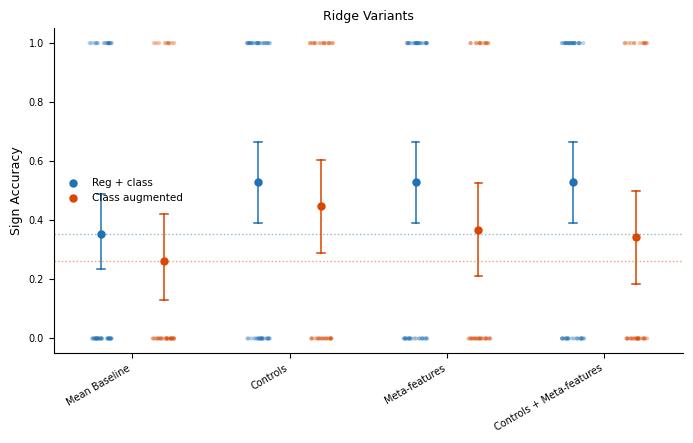

Saved figure: /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/figures/config_2_781b7f9c27428458/predictive/combined_matrices__tree__sign_correct.pdf


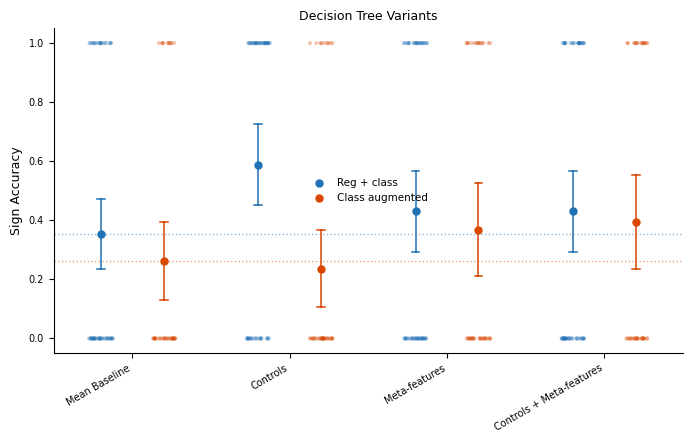

Saved figure: /work/mherre/tabular-meta-feature-analysis/meta-feature-analysis/figures/config_2_781b7f9c27428458/predictive/combined_matrices__xgboost__sign_correct.pdf


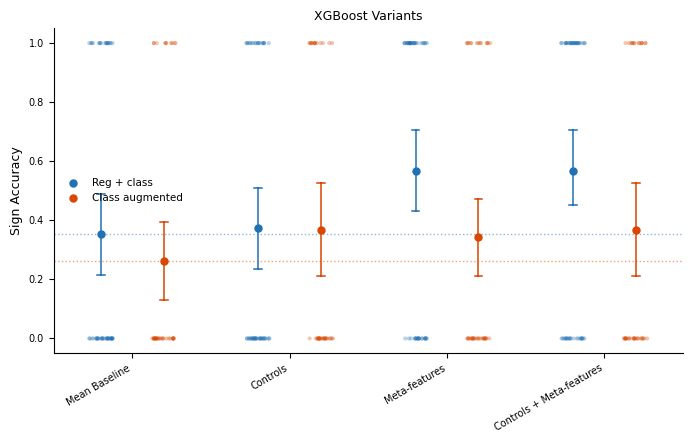

,saved_figure
0,/work/mherre/tabular-meta-feature-analysis/met...
1,/work/mherre/tabular-meta-feature-analysis/met...
2,/work/mherre/tabular-meta-feature-analysis/met...


In [5]:
PREDICTIVE_PLOT_METRIC = "sign_correct"
PREDICTIVE_PLOT_FAMILY_ORDER = ["ridge", "tree", "xgboost", "tabpfn"]
PREDICTIVE_PLOT_FAMILY_LABELS = {
    "ridge": "Ridge",
    "tree": "Decision Tree",
    "xgboost": "XGBoost",
    "tabpfn": "TabPFN",
}
PREDICTIVE_PLOT_MODEL_LABELS = {
    "mean_baseline": "Mean Baseline",
    "ridge_controls": "Controls",
    "ridge_meta_features": "Meta-features",
    "ridge_controls_plus_meta_features": "Controls + Meta-features",
    "ridge_robust_features": "Robust",
    "ridge_controls_plus_robust_features": "Controls + Robust",
    "decision_tree_controls": "Controls",
    "decision_tree_meta_features": "Meta-features",
    "decision_tree_controls_plus_meta_features": "Controls + Meta-features",
    "decision_tree_robust_features": "Robust",
    "decision_tree_controls_plus_robust_features": "Controls + Robust",
    "xgboost_controls": "Controls",
    "xgboost_meta_features": "Meta-features",
    "xgboost_controls_plus_meta_features": "Controls + Meta-features",
    "xgboost_robust_features": "Robust",
    "xgboost_controls_plus_robust_features": "Controls + Robust",
    "tabpfn_controls": "Controls",
    "tabpfn_meta_features": "Meta-features",
    "tabpfn_controls_plus_meta_features": "Controls + Meta-features",
    "tabpfn_robust_features": "Robust",
    "tabpfn_controls_plus_robust_features": "Controls + Robust",
}
PREDICTIVE_PLOT_METRIC_LABELS = {
    "absolute_error": "Absolute prediction error",
    "sign_correct": "Sign Accuracy",
}
PREDICTIVE_PLOT_METRIC_SUMMARIES = {
    "absolute_error": ("median_prediction_error", "median"),
    "sign_correct": ("sign_accuracy", "mean"),
}
PREDICTIVE_PLOT_TABLE_ORDER = ["regression_classification", "classification_augmented"]
PREDICTIVE_PLOT_TABLE_LABELS = {
    "regression_classification": "Reg + class",
    "classification_augmented": "Class augmented",
}
PREDICTIVE_PLOT_TABLE_COLORS = {
    "regression_classification": "#2171b5",
    "classification_augmented": "#d94701",
}
PREDICTIVE_PLOT_TABLE_BOX_COLORS = {
    "regression_classification": "#8fb8de",
    "classification_augmented": "#f5c196",
}
PREDICTIVE_SAVED_FIGURES: list[Path] = []


def _plot_slug(value: str) -> str:
    return "".join(
        character if character.isalnum() else "_"
        for character in str(value).strip().lower()
    ).strip("_")


def _save_predictive_figure(fig: plt.Figure, stem: str) -> Path | None:
    if not PREDICTIVE_EXPORT_FIGURES:
        return None
    export_dir = Path(PREDICTIVE_FIGURE_EXPORT_DIR)
    export_dir.mkdir(parents=True, exist_ok=True)
    path = export_dir / f"{stem}.pdf"
    fig.savefig(
        path,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.02,
        metadata={"Creator": "02_mfa.ipynb"},
    )
    PREDICTIVE_SAVED_FIGURES.append(path)
    print(f"Saved figure: {path}")
    return path


def _predictive_error_boxplot_data(
    predictions: pd.DataFrame,
    *,
    model_family: str,
) -> pd.DataFrame:
    if predictions.empty:
        return pd.DataFrame()
    plot_data = predictions[
        predictions["model_family"].isin(["mean", model_family])
    ].copy()
    if plot_data.empty:
        return plot_data
    plot_data["absolute_error"] = (
        plot_data["y_true"].astype(float) - plot_data["y_pred"].astype(float)
    ).abs()
    y_true_sign = np.sign(plot_data["y_true"].astype(float))
    y_pred_sign = np.sign(plot_data["y_pred"].astype(float))
    plot_data["sign_correct"] = (y_true_sign == y_pred_sign).astype(float)
    plot_data.loc[y_true_sign.eq(0), "sign_correct"] = np.nan
    plot_data["plot_family"] = model_family
    plot_data["model_label"] = (
        plot_data["model"].map(PREDICTIVE_PLOT_MODEL_LABELS).fillna(plot_data["model"])
    )
    return plot_data


def _combined_model_order(plot_data: pd.DataFrame) -> list[str]:
    all_labels = set(plot_data["model_label"])
    seen: set[str] = set()
    ordered: list[str] = []
    for m in predictive_metrics["model"].tolist():
        label = PREDICTIVE_PLOT_MODEL_LABELS.get(m, m)
        if label not in seen and label in all_labels:
            seen.add(label)
            ordered.append(label)
    ordered += [l for l in all_labels if l not in seen]
    baseline_label = PREDICTIVE_PLOT_MODEL_LABELS.get("mean_baseline", "Mean baseline")
    if baseline_label in ordered:
        ordered = [baseline_label, *[l for l in ordered if l != baseline_label]]
    return ordered


def plot_predictive_error_boxplots(
    predictions: pd.DataFrame = predictive_predictions,
    *,
    metric: str = PREDICTIVE_PLOT_METRIC,
) -> None:
    if metric not in PREDICTIVE_PLOT_METRIC_LABELS:
        raise ValueError(
            f"Unknown predictive plot metric {metric!r}. Choose one of "
            f"{sorted(PREDICTIVE_PLOT_METRIC_LABELS)}."
        )
    if predictions.empty or "model_family" not in predictions.columns:
        print("No predictive prediction rows are available to plot.")
        return

    available_families = set(predictions["model_family"])
    model_families = [
        family
        for family in PREDICTIVE_PLOT_FAMILY_ORDER
        if family in available_families
    ]
    for model_family in model_families:
        plot_data = _predictive_error_boxplot_data(
            predictions,
            model_family=model_family,
        )
        if plot_data.empty:
            continue

        hue_order = [
            t
            for t in PREDICTIVE_PLOT_TABLE_ORDER
            if t in set(plot_data["analysis_table"])
        ]
        if not hue_order:
            continue

        order = _combined_model_order(plot_data)
        if not order:
            continue

        width = max(7.0, 1.55 * len(order))
        fig, ax = plt.subplots(figsize=(width, 4.5))

        # Match dodge offset between stripplot and pointplot.
        # seaborn's stripplot/boxplot with dodge=True splits each category
        # into n_hue equal sub-bins of total width 0.8; pointplot's numeric
        # `dodge` is the *total* spread between hue groups, so use 0.8*(n-1)/n.
        n_hue = max(len(hue_order), 1)
        point_dodge = 0.8 * (n_hue - 1) / n_hue if n_hue > 1 else 0.0

        if metric == "sign_correct":
            for analysis_table in hue_order:
                table_data = plot_data[plot_data["analysis_table"] == analysis_table]
                baseline_mean = table_data.loc[
                    table_data["model"] == "mean_baseline", metric
                ].mean()
                if not np.isnan(baseline_mean):
                    ax.axhline(
                        baseline_mean,
                        color=PREDICTIVE_PLOT_TABLE_COLORS[analysis_table],
                        linestyle=":",
                        linewidth=1.0,
                        alpha=0.5,
                        zorder=0,
                    )
            sns.stripplot(
                data=plot_data,
                x="model_label",
                y=metric,
                hue="analysis_table",
                hue_order=hue_order,
                order=order,
                dodge=True,
                palette=PREDICTIVE_PLOT_TABLE_COLORS,
                ax=ax,
                alpha=0.30,
                jitter=0.15,
                size=3,
                legend=False,
            )
            sns.pointplot(
                data=plot_data,
                x="model_label",
                y=metric,
                hue="analysis_table",
                hue_order=hue_order,
                order=order,
                dodge=point_dodge,
                palette=PREDICTIVE_PLOT_TABLE_COLORS,
                ax=ax,
                errorbar=("ci", 95),
                capsize=0.05,
                linestyle="none",
                markersize=4,
                err_kws={"linewidth": 1.1},
            )
        else:
            sns.boxplot(
                data=plot_data,
                x="model_label",
                y=metric,
                hue="analysis_table",
                hue_order=hue_order,
                order=order,
                dodge=True,
                palette=PREDICTIVE_PLOT_TABLE_BOX_COLORS,
                ax=ax,
                showfliers=True,
            )

        # Relabel legend entries to friendly names
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles,
            [PREDICTIVE_PLOT_TABLE_LABELS.get(l, l) for l in labels],
            title=None,
            frameon=False,
            fontsize="small",
        )

        ax.set_title(f"{PREDICTIVE_PLOT_FAMILY_LABELS[model_family]} Variants")
        ax.set_xlabel("")
        ax.set_ylabel(PREDICTIVE_PLOT_METRIC_LABELS[metric])
        if metric == "sign_correct":
            ax.set_ylim(-0.05, 1.05)
        ax.tick_params(axis="x", labelrotation=30)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")
        sns.despine(ax=ax)
        fig.tight_layout()
        stem = "__".join(
            [
                "combined_matrices",
                _plot_slug(model_family),
                _plot_slug(metric),
            ]
        )
        _save_predictive_figure(fig, stem)
        plt.show()


if predictive_predictions.empty or "model_family" not in predictive_predictions.columns:
    predictive_error_boxplot_data = pd.DataFrame()
else:
    predictive_error_boxplot_frames = [
        _predictive_error_boxplot_data(predictive_predictions, model_family=family)
        for family in PREDICTIVE_PLOT_FAMILY_ORDER
        if family in set(predictive_predictions["model_family"])
    ]
    predictive_error_boxplot_data = (
        pd.concat(predictive_error_boxplot_frames, ignore_index=True)
        if predictive_error_boxplot_frames
        else pd.DataFrame()
    )
if predictive_error_boxplot_data.empty:
    predictive_error_boxplot_summary = pd.DataFrame()
    display(predictive_error_boxplot_summary)
else:
    summary_column, summary_agg = PREDICTIVE_PLOT_METRIC_SUMMARIES[
        PREDICTIVE_PLOT_METRIC
    ]
    predictive_error_boxplot_summary = (
        predictive_error_boxplot_data.groupby(
            ["analysis_table", "plot_family", "model"],
            as_index=False,
        )
        .agg(
            n=(PREDICTIVE_PLOT_METRIC, "count"),
            **{summary_column: (PREDICTIVE_PLOT_METRIC, summary_agg)},
        )
        .sort_values(["analysis_table", "plot_family", "model"])
        .reset_index(drop=True)
    )
    display(predictive_error_boxplot_summary)
plot_predictive_error_boxplots(metric=PREDICTIVE_PLOT_METRIC)
if PREDICTIVE_SAVED_FIGURES:
    display(
        pd.DataFrame({"saved_figure": [str(path) for path in PREDICTIVE_SAVED_FIGURES]})
    )

## Reporting Rule

The predictive claim is limited to out-of-sample performance relative to the mean-only baseline and the fixed-control baseline for the corresponding dataset-level matrix. Ridge regression remains the primary predictive model, including the fixed-controls-plus-robust-features variant when `01_mfa.ipynb` reports robust survivors. The shallow decision tree and optional strongly regularized XGBoost model are nonlinear sensitivity checks; they are useful only if they improve MAE/RMSE under leave-one-dataset-out evaluation on the corresponding dataset-level matrix. Full-matrix models show weak or no robust practical improvement under this protocol. Ridge coefficient tables are descriptive only and are not interpreted as causal effects or post-selection significance tests.
